Running K-Means for k=1 to 10...


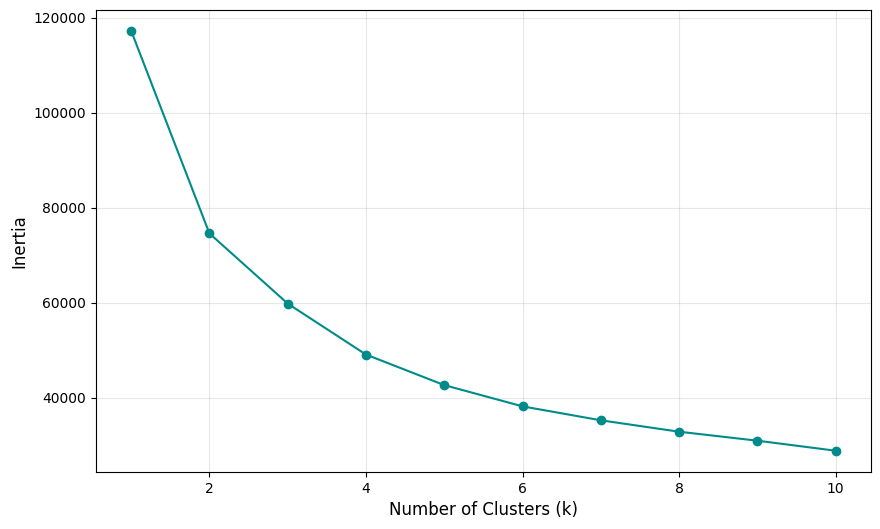

Clustering complete. Labels added to dataframe for k=2.
cluster_label
0    6808
1    6221
Name: count, dtype: int64
Clustering complete. Labels added to dataframe for k=3.
cluster_label
0    6751
1    6236
2      42
Name: count, dtype: int64
Clustering complete. Labels added to dataframe for k=4.
cluster_label
1    6072
3    4466
0    2451
2      40
Name: count, dtype: int64


In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.losses import CategoricalCrossentropy

# --- 1. DATA LOADING & PREPROCESSING ---
# (Keeping your original logic here)
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month

# Seasonal Encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Z-Score Calculation (Monthly Stats)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()
df = df.merge(stats, on='month')
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Rolling Precip
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()

# Drop rows with NaNs caused by rolling windows
df = df.dropna()

# --- 2. FEATURE SELECTION ---
# We exclude the 'category' you manually created because we want K-Means 
# to find the categories itself based on the raw variables.
top_features = ['sro', 'ssro', 'ssr', 'ssrd', 'swvl1', 'swvl2', 'month_cos', 'tp_30d_sum', 'tp_90d_sum']
X_raw = df[top_features].values

# --- 3. SCALING ---
# CRITICAL: K-Means uses Euclidean distance, so features must be on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- 4. THE ELBOW METHOD ---
# We calculate the "Inertia" (sum of squared distances to centroids) for different k values.
inertia = []
K_range = range(1, 11) 

print("Running K-Means for k=1 to 10...")
for k in K_range:
    # random_state ensures you get the same result every time you run it
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# --- 5. VISUALIZATION ---

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='darkcyan')
# plt.title('Elbow Method: Finding the Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- 6. APPLYING THE CHOSEN K ---
# Based on the plot, pick the 'k' where the drop levels off (the "elbow").
# Let's assume the elbow is at 3 for this example.
chosen_k = 2
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df['cluster_label'] = final_kmeans.fit_predict(X_scaled)

print(f"Clustering complete. Labels added to dataframe for k={chosen_k}.")
print(df['cluster_label'].value_counts())

chosen_k = 3
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df['cluster_label'] = final_kmeans.fit_predict(X_scaled)

print(f"Clustering complete. Labels added to dataframe for k={chosen_k}.")
print(df['cluster_label'].value_counts())

chosen_k = 4
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df['cluster_label'] = final_kmeans.fit_predict(X_scaled)

print(f"Clustering complete. Labels added to dataframe for k={chosen_k}.")
print(df['cluster_label'].value_counts())



Calculating metrics for k=2 to 10...
k=2 | Inertia: 74576.97 | Silhouette: 0.3865
k=3 | Inertia: 59793.53 | Silhouette: 0.3905
k=4 | Inertia: 49057.17 | Silhouette: 0.3405
k=5 | Inertia: 42622.53 | Silhouette: 0.3015
k=6 | Inertia: 38147.65 | Silhouette: 0.2776
k=7 | Inertia: 35211.97 | Silhouette: 0.2756
k=8 | Inertia: 32806.88 | Silhouette: 0.2390
k=9 | Inertia: 30916.88 | Silhouette: 0.2253
k=10 | Inertia: 28803.85 | Silhouette: 0.2130


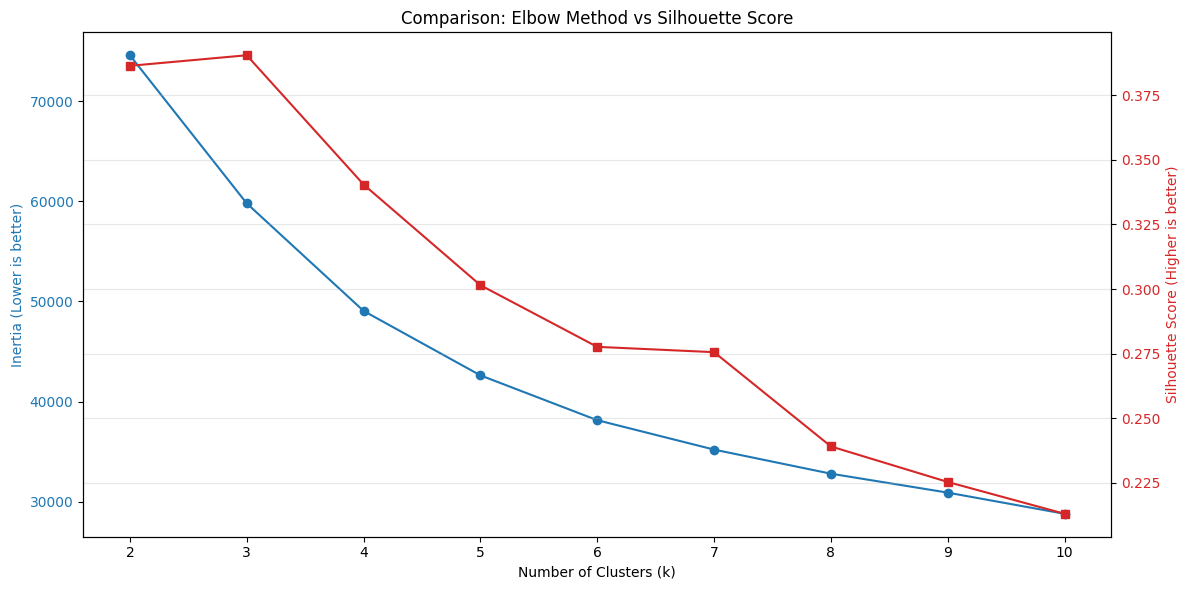

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. DATA LOADING & PREPROCESSING ---
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

# Feature Engineering
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)

# Z-Score and Rolling Stats
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()
df = df.merge(stats, on='month')
df['tp_30d_sum'] = df['tp'].rolling(window=30).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90).sum()
df = df.dropna()

# Feature Selection (Excluding 'category' to keep it unsupervised)
top_features = ['sro', 'ssro', 'ssr', 'ssrd', 'swvl1', 'swvl2', 'month_cos', 'tp_30d_sum', 'tp_90d_sum']
X_raw = df[top_features].values

# --- 2. SCALING ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- 3. CALCULATING METRICS ---
inertia = []
sil_scores = []
K_range = range(2, 11) # Silhouette requires at least 2 clusters

print("Calculating metrics for k=2 to 10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Elbow Metric
    inertia.append(kmeans.inertia_)
    
    # Silhouette Metric (Using a sample for speed if dataset is huge)
    # If the code is slow, use: sample_size=10000
    score = silhouette_score(X_scaled, labels, metric='euclidean', sample_size=10000)
    sil_scores.append(score)
    print(f"k={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette: {score:.4f}")

# --- 4. VISUALIZATION ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Lower is better)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette Score
ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Higher is better)', color=color)
ax2.plot(K_range, sil_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison: Elbow Method vs Silhouette Score')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

Lead time analysis for k=4

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

def run_feature_selection(df, lead_time=30):
    # Clean up columns
    # We want to keep the original features, but drop targets/time
    cols_to_exclude = ['time']
    X = df.drop(columns=[c for c in cols_to_exclude if c in df.columns])
    
    # Create the shifted target manually (no sequences needed for XGBoost)
    # We want to predict the category 'lead_time' days into the future
    y = df['cluster_label'].shift(-lead_time)
    
    # Remove the last 'lead_time' rows where target is now NaN
    X = X.iloc[:-lead_time]
    y = y.iloc[:-lead_time]
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Initialize and Train XGBoost
    # We use a shallow tree (max_depth=3 or 5) to prevent it from picking up on 'accidental' noise
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    
    print(f"Analyzing feature importance for {lead_time}-day lead time...")
    model.fit(X_train, y_train)
    
    # Extract and Plot Importances
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    print(importances.head(15))
    
    return importances

features_to_drop = ['time', 'mean'] 
df_reduced = df.drop(columns=features_to_drop)
feature_results = run_feature_selection(df_reduced, lead_time=7)

# Print the top 15 features to use in your LSTM
top_15 = feature_results['Feature'].head(15).tolist()
print("\nTop 15 Features recommended for your LSTM:")
print(top_15)

feature_results = run_feature_selection(df_reduced, lead_time=14)

# Print the top 15 features to use in your LSTM
top_15 = feature_results['Feature'].head(15).tolist()
print("\nTop 15 Features recommended for your LSTM:")
print(top_15)

feature_results = run_feature_selection(df_reduced, lead_time=21)

# Print the top 15 features to use in your LSTM
top_15 = feature_results['Feature'].head(15).tolist()
print("\nTop 15 Features recommended for your LSTM:")
print(top_15)

feature_results = run_feature_selection(df_reduced, lead_time=30)

# Print the top 15 features to use in your LSTM
top_15 = feature_results['Feature'].head(15).tolist()
print("\nTop 15 Features recommended for your LSTM:")
print(top_15)

Analyzing feature importance for 7-day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:49:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Feature  Importance
32  cluster_label    0.609330
27      month_cos    0.210098
21          swvl2    0.016668
29            std    0.010759
1             pev    0.010256
28      month_sin    0.008934
11           ssrd    0.008891
30     tp_30d_sum    0.008876
26          month    0.008373
20          swvl1    0.007213
18           stl2    0.006864
22          swvl3    0.006847
31     tp_90d_sum    0.006752
23          swvl4    0.006635
17           stl1    0.006635

Top 15 Features recommended for your LSTM:
['cluster_label', 'month_cos', 'swvl2', 'std', 'pev', 'month_sin', 'ssrd', 'tp_30d_sum', 'month', 'swvl1', 'stl2', 'swvl3', 'tp_90d_sum', 'swvl4', 'stl1']
Analyzing feature importance for 14-day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:49:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Feature  Importance
32  cluster_label    0.529634
27      month_cos    0.243831
28      month_sin    0.020813
21          swvl2    0.019814
9            slhf    0.013209
26          month    0.013052
30     tp_30d_sum    0.012986
29            std    0.012908
11           ssrd    0.011741
23          swvl4    0.010074
22          swvl3    0.009680
7            ssro    0.009346
31     tp_90d_sum    0.009314
19             sd    0.008468
18           stl2    0.006413

Top 15 Features recommended for your LSTM:
['cluster_label', 'month_cos', 'month_sin', 'swvl2', 'slhf', 'month', 'tp_30d_sum', 'std', 'ssrd', 'swvl4', 'swvl3', 'ssro', 'tp_90d_sum', 'sd', 'stl2']
Analyzing feature importance for 21-day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:50:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Feature  Importance
27      month_cos    0.400057
32  cluster_label    0.240523
28      month_sin    0.096151
9            slhf    0.026588
20          swvl1    0.021251
26          month    0.019066
29            std    0.018653
21          swvl2    0.018153
30     tp_30d_sum    0.015941
22          swvl3    0.013933
18           stl2    0.012706
23          swvl4    0.012419
7            ssro    0.010809
31     tp_90d_sum    0.009139
11           ssrd    0.008216

Top 15 Features recommended for your LSTM:
['month_cos', 'cluster_label', 'month_sin', 'slhf', 'swvl1', 'month', 'std', 'swvl2', 'tp_30d_sum', 'swvl3', 'stl2', 'swvl4', 'ssro', 'tp_90d_sum', 'ssrd']
Analyzing feature importance for 30-day lead time...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:50:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


       Feature  Importance
27   month_cos    0.426304
28   month_sin    0.250436
26       month    0.044148
30  tp_30d_sum    0.026935
11        ssrd    0.026837
23       swvl4    0.019926
22       swvl3    0.017525
21       swvl2    0.015169
7         ssro    0.015116
29         std    0.013995
18        stl2    0.011679
31  tp_90d_sum    0.011626
16         skt    0.010878
20       swvl1    0.009379
17        stl1    0.009086

Top 15 Features recommended for your LSTM:
['month_cos', 'month_sin', 'month', 'tp_30d_sum', 'ssrd', 'swvl4', 'swvl3', 'swvl2', 'ssro', 'std', 'stl2', 'tp_90d_sum', 'skt', 'swvl1', 'stl1']


Starting Lead-Time Analysis...


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step



c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


...

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

 LEAD-TIME PREDICTABILITY ANALYSIS 
 Lead Time (Days)  LSTM Accuracy (%)  CNN Accuracy (%)  Transformer Accuracy (%)  XGBoost Accuracy (%)  Persistence Baseline (%)  LSTM F1 Macro (%)  CNN F1 Macro (%)  Transformer F1 Macro (%)  XGBoost F1 Macro (%)  Persistence F1 Macro (%)
                1              89.92             90.81                     84.77                 93.42                     92.96              71.16             68.14                     63.46                 70.06                     71.99
                2              88.15             85.88                     81.73                 90.46                     90.50              66.75             64.15                     62.24                 67.55                     76.62
                3              86.04        

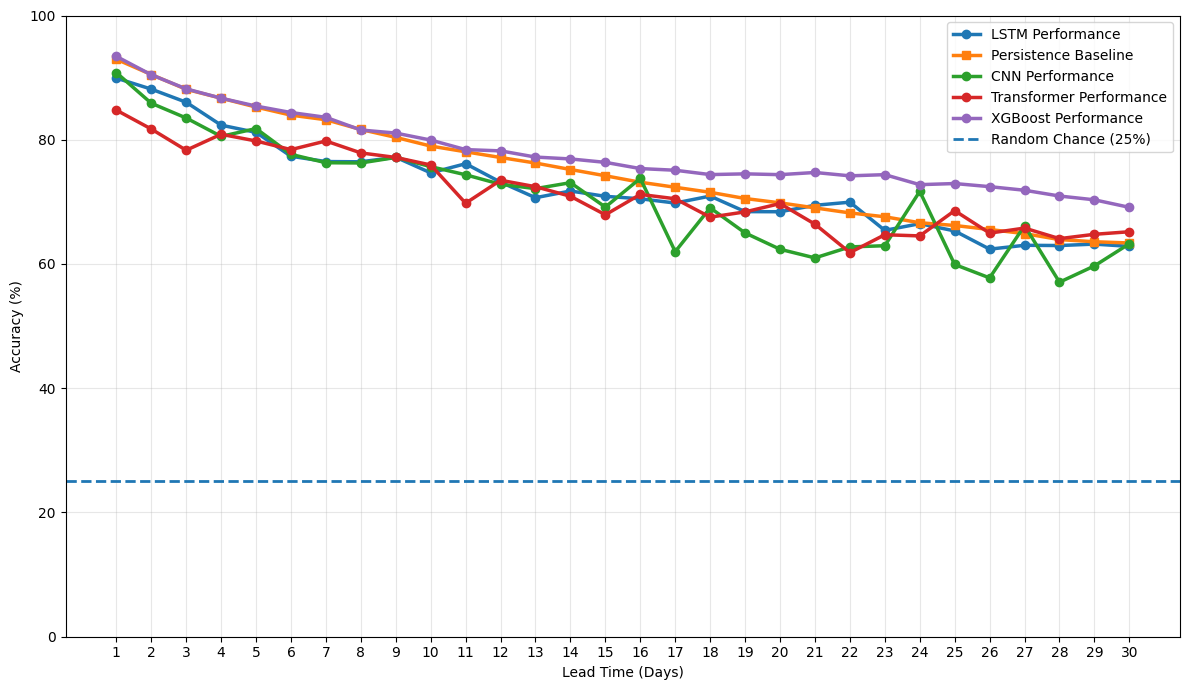

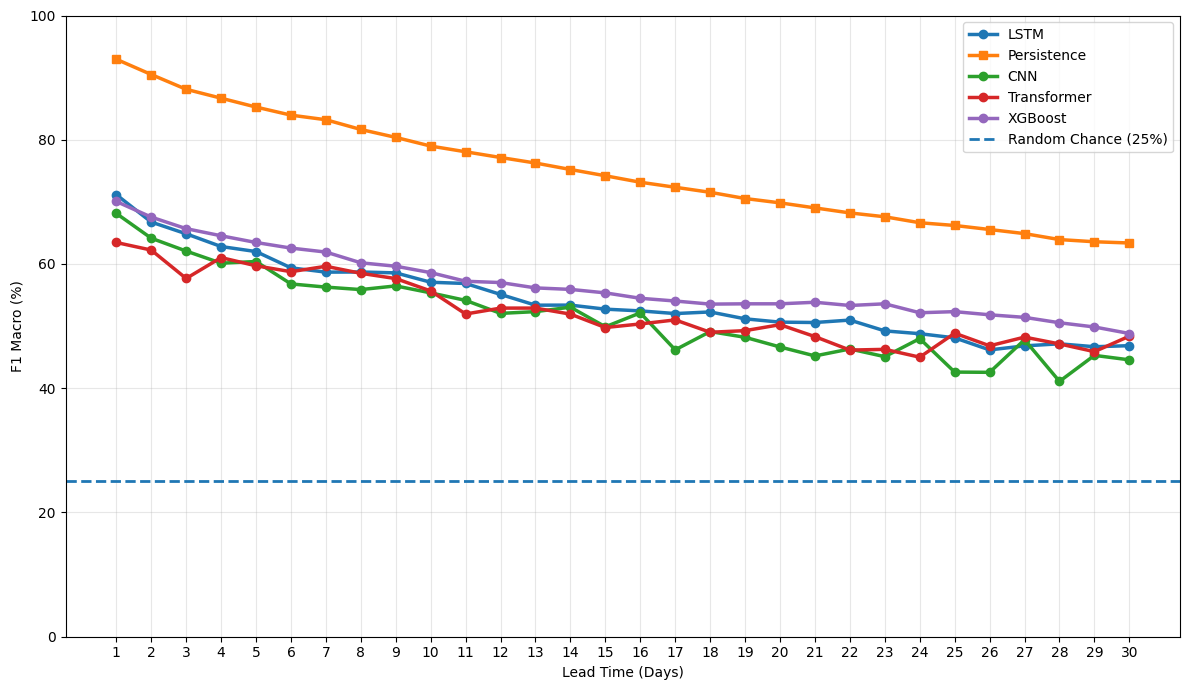

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, optimizers, losses, Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

def train_evaluate_lstm(X_train, X_test, y_train, y_test, weights_dict, lead_time):
    model = Sequential([
        layers.LSTM(16, input_shape=(X_train.shape[1], X_train.shape[2]),
                    kernel_regularizer=regularizers.l2(0.01),
                    recurrent_regularizer=regularizers.l2(0.01),
                    dropout=0.3, recurrent_dropout=0.2),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(optimizer='adam', loss=losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
              callbacks=[early_stop], class_weight=weights_dict, verbose=0)

    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1))
    f1 = f1_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1), average='macro')
    return acc, f1, model

# --- 3. CNN MODEL ---
def build_regularized_cnn(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(32, 5, activation='relu', kernel_regularizer=regularizers.l2(0.01), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(64, 3, activation='relu', kernel_regularizer=regularizers.l2(0.01), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer=optimizers.Adam(0.001), loss=losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model

def train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    model = build_regularized_cnn((X_train.shape[1], X_train.shape[2]))
    callbacks = [EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)]

    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32,
              class_weight=class_weights_dict, callbacks=callbacks, verbose=0)

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    f1 = f1_score(np.argmax(y_test, axis=1), y_pred, average='macro')
    return acc, f1, model

# --- 4. TRANSFORMER MODEL ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

def build_transformer_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(4, activation="softmax")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights_dict, lead_time):
    model = build_transformer_model((X_train.shape[1], X_train.shape[2]))
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
              callbacks=[early_stop], class_weight=class_weights_dict, verbose=0)

    acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1))
    f1 = f1_score(np.argmax(y_test, axis=1), np.argmax(model.predict(X_test), axis=1), average='macro')
    return acc, f1, model

# --- 5. XGBOOST MODEL ---
def train_evaluate_xgboost(X_train, y_train_flat, X_test, y_test_flat, class_weights_dict, lead_time):
    """
    Applies weights by mapping the class_weight dict to a sample_weight array.
    Flattens 3D input to 2D for tree-based processing.
    """
    # Flatten 3D (samples, time, features) -> 2D (samples, time*features)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Create sample weights array based on y_train_flat
    sample_weights = np.array([class_weights_dict[t] for t in y_train_flat])

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=4,
        random_state=42
    )

    model.fit(X_train_flat, y_train_flat, sample_weight=sample_weights)

    y_pred = model.predict(X_test_flat)
    acc = accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred, average='macro')
    return acc, f1, model

def prepare_data_for_lead_time(df, lead_time, seq_length=30):
    """
    Dynamically shifts the target variable to the requested lead time
    and prepares the 3D sequences for the LSTM.
    Also returns persistence-baseline labels.
    """
    # cols_to_drop = ['target_next_month', 'time']
    # features_df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'cluster_label']
    features_df = df[top_features]

    y_raw = df['cluster_label'].values
    X_raw = features_df.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    X_seq, y_seq, y_persist = [], [], []

    for i in range(len(X_scaled) - seq_length - lead_time + 1):
        X_seq.append(X_scaled[i:i + seq_length])

        target_idx = i + seq_length + lead_time - 1
        y_seq.append(y_raw[target_idx])

        # Persistence baseline: predict the last observed class in the input window
        y_persist.append(y_raw[i + seq_length - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq).astype(int)
    y_persist = np.array(y_persist).astype(int)

    y_encoded = to_categorical(y_seq, num_classes=4)

    split_idx = int(len(X_seq) * 0.8)

    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

    y_persist_train = y_persist[:split_idx]
    y_persist_test = y_persist[split_idx:]
    y_true_test = y_seq[split_idx:]

    y_train_flat = np.argmax(y_train, axis=1)
    weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_flat),
        y=y_train_flat
    )
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    return X_train, X_test, y_train, y_test, class_weights_dict, y_persist_test, y_true_test


# --- 3. HERO PLOT ---
def plot_hero_predictability(results_df):
    plt.figure(figsize=(12, 7))

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['LSTM Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='LSTM Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Persistence Baseline (%)'],
        marker='s',
        linewidth=2.5,
        label='Persistence Baseline'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['CNN Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='CNN Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Transformer Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='Transformer Performance'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['XGBoost Accuracy (%)'],
        marker='o',
        linewidth=2.5,
        label='XGBoost Performance'
    )

    plt.axhline(
        y=25,
        linestyle='--',
        linewidth=2,
        label='Random Chance (25%)'
    )

    plt.xlabel('Lead Time (Days)')
    plt.ylabel('Accuracy (%)')
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hero_predictability_f1(results_df):
    plt.figure(figsize=(12, 7))

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['LSTM F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='LSTM'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Persistence Baseline (%)'],
        marker='s',
        linewidth=2.5,
        label='Persistence'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['CNN F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='CNN'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Transformer F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='Transformer'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['XGBoost F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='XGBoost'
    )

    plt.axhline(
        y=25,
        linestyle='--',
        linewidth=2,
        label='Random Chance (25%)'
    )

    plt.xlabel('Lead Time (Days)')
    plt.ylabel('F1 Macro (%)')
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


import gc

# --- 5. MAIN EXECUTION LOOP ---
lead_times_to_test = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30] 
results_list = []

print("Starting Lead-Time Analysis...")

for lt in lead_times_to_test:
    X_train, X_test, y_train, y_test, class_weights, y_persist_test, y_true_test = prepare_data_for_lead_time(
        df, lead_time=lt)
    
    # LSTM
    val_acc_lstm, val_f1_lstm, _ = train_evaluate_lstm(X_train, X_test, y_train, y_test, class_weights, lead_time=lt)

    # Persistence
    persistence_acc = np.mean(y_persist_test == y_true_test)
    persistence_f1 = f1_score(y_true_test, y_persist_test, average='macro')

    # CNN
    val_acc_cnn, val_f1_cnn, _ = train_evaluate_cnn(X_train, y_train, X_test, y_test, class_weights, lead_time=lt)

    # transformer
    val_acc_transformer, val_f1_transformer, _ = train_evaluate_transformer(X_train, y_train, X_test, y_test, class_weights, lt)
    
    # XGboost
    # "Squash" X into 2D for XGBoost
    # This turns (Samples, 30, 11) into (Samples, 330)
    X_train_xgb = X_train.reshape(X_train.shape[0], -1)
    X_test_xgb = X_test.reshape(X_test.shape[0], -1)

    # Convert y back to Integers for XGBoost
    # Turns [[1,0,0], [0,1,0]] into [0, 1]
    y_train_xgb = np.argmax(y_train, axis=1)
    y_test_xgb = np.argmax(y_test, axis=1)

    val_acc_xgboost, val_f1_xgboost,_ = train_evaluate_xgboost(X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, class_weights, lead_time=lt)

    results_list.append({
        'Lead Time (Days)': lt,
        'LSTM Accuracy (%)': round(val_acc_lstm * 100, 2),
        'CNN Accuracy (%)': round(val_acc_cnn * 100, 2),
        'Transformer Accuracy (%)': round(val_acc_transformer * 100, 2),
        'XGBoost Accuracy (%)': round(val_acc_xgboost * 100, 2),
        'Persistence Baseline (%)': round(persistence_acc * 100, 2),
        'LSTM F1 Macro (%)': round(val_f1_lstm * 100, 2),
        'CNN F1 Macro (%)': round(val_f1_cnn * 100, 2),
        'Transformer F1 Macro (%)': round(val_f1_transformer * 100, 2),
        'XGBoost F1 Macro (%)': round(val_f1_xgboost * 100, 2),
        'Persistence F1 Macro (%)': round(persistence_f1 * 100, 2)
    })

    # CRITICAL: CLEAR MEMORY
    # Wipe the TensorFlow/Keras models from RAM/GPU
    tf.keras.backend.clear_session()
    
    # Delete the large data arrays to free up space
    del X_train, X_test, X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb, y_train, y_test
    
    # Force Python to clean up
    gc.collect()


results_df = pd.DataFrame(results_list)

print("\n" + "=" * 50)
print(" LEAD-TIME PREDICTABILITY ANALYSIS ")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

# Final hero plot
plot_hero_predictability(results_df)
plot_hero_predictability_f1(results_df)

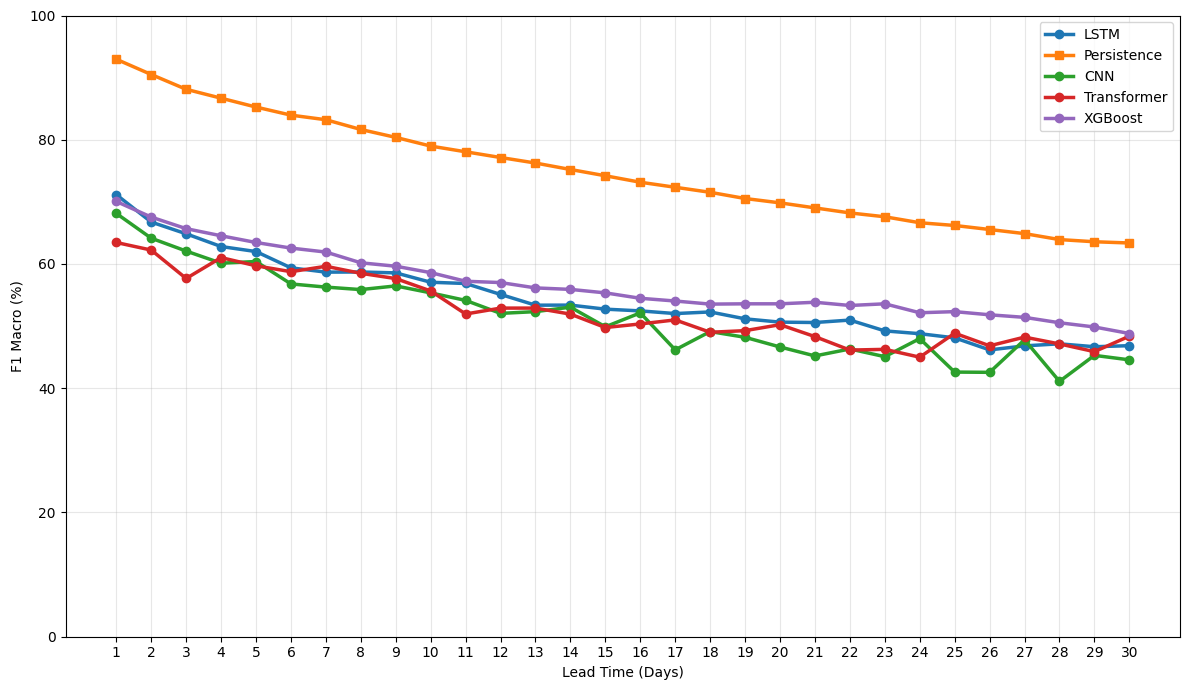

In [ ]:
def plot_hero_predictability_f1(results_df):
    plt.figure(figsize=(12, 7))

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['LSTM F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='LSTM'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Persistence Baseline (%)'],
        marker='s',
        linewidth=2.5,
        label='Persistence'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['CNN F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='CNN'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['Transformer F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='Transformer'
    )

    plt.plot(
        results_df['Lead Time (Days)'],
        results_df['XGBoost F1 Macro (%)'],
        marker='o',
        linewidth=2.5,
        label='XGBoost'
    )

    plt.xlabel('Lead Time (Days)')
    plt.ylabel('F1 Macro (%)')
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_hero_predictability_f1(results_df)